## Face Detection Setup with Haar Cascade

In [26]:
import cv2

# Read the image file
img = cv2.imread(r"people2.jpg")

# Create a copy to preserve the original image
copied_img = img.copy()

# Convert the image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Initialize Haar Cascade classifier for frontal face detection
haar_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml") 

<details>
<summary><b>How Haar Cascade Works</b> (click to expand)</summary>

- **Training** — The model learns from thousands of face and non-face images.

- **Sliding Window** — A window scans the image at multiple scales and positions.

- **Feature Detection** — It looks for simple patterns like `edges`, `lines`, and contrasts between `dark`/`light` regions using **Haar-like features**.

- **Cascade of Stages** — Each region passes through multiple classifier stages:
  - If a region fails **any** stage → `rejected immediately`
  - Only regions passing **all stages** → `marked as a face`

- **Speed Optimization** — Non-faces are rejected early in the cascade using `if-else`-style logic, making detection very fast.

> **Think of it as:**  
> A rapid series of `yes`/`no` questions about pixel patterns.  
> Only regions that answer `"yes"` to **every question** are labeled as faces.

</details>

## Tuning Haar Cascade: Impact of `minNeighbors` Parameter

In [ ]:
# Detect faces with low neighbor requirement (more detections, possible false positives)
faces_neighbors_3 = haar_cascade.detectMultiScale(image=gray_img,
                                                  scaleFactor=1.1,
                                                  minNeighbors=3)


# Detect faces with high neighbor requirement (fewer false positives, may miss some faces)
faces_neighbors_15 = haar_cascade.detectMultiScale(image=gray_img,
                                                   scaleFactor=1.1,
                                                   minNeighbors=15)

## Drawing Face Detections on images

In [28]:
for(x, y, w, h) in faces_neighbors_3:
    cv2.rectangle(img=img, pt1=(x, y), pt2=(x+w, y+h), color=(0, 255, 0), thickness=2)
    
for(x, y, w, h) in faces_neighbors_15:
    cv2.rectangle(img=copied_img, pt1=(x, y), pt2=(x+w, y+h), color=(0, 255, 0), thickness=2)

<details>
<summary><b>scaleFactor & minNeighbors</b> (click to expand)</summary>

---

## What is `scaleFactor`?

### The problem:

Faces come in different sizes:

- A face **close to the camera** looks **large** (takes many pixels)
- A face **far away** looks **small** (takes few pixels)

The sliding window has a **fixed size**. Without `scaleFactor`, it would only detect faces matching that exact size → only one specific distance.

### The solution

`scaleFactor` shrinks the image repeatedly. Large faces eventually become small enough to match the fixed window.

### How it works

| `scaleFactor` | Effect |
|---------------|--------|
| `1.05` | Tiny steps → many scales → slower, more accurate |
| `1.1`  | Good balance (common default) |
| `1.3`  | Big steps → fewer scales → faster, may miss faces |

### One-line summary

> `scaleFactor` controls how much the image shrinks each pass — smaller = more precise, larger = faster.

---

## What is `minNeighbors`?

### The problem:

The detector may find multiple overlapping rectangles around the same face:

- Slight shifts in the sliding window produce multiple positive detections
- Without filtering, you get messy, redundant boxes around one face

### The solution

`minNeighbors` specifies how many overlapping detections are needed to keep a rectangle.

- Each candidate rectangle counts how many nearby detections "vote" for it
- Only rectangles with at least `minNeighbors` overlapping detections are kept

### How it works

| `minNeighbors` | Effect |
|----------------|--------|
| `2` | Low threshold → more detections, some false positives |
| `3–5` | Good balance (common default is 5) |
| `6+` | High threshold → fewer false positives, may miss some faces |

### One-line summary

> `minNeighbors` filters out weak detections — higher values mean more confidence but risk missing real faces.

---

## Visualizing the Effect of `minNeighbors` on Face Detection

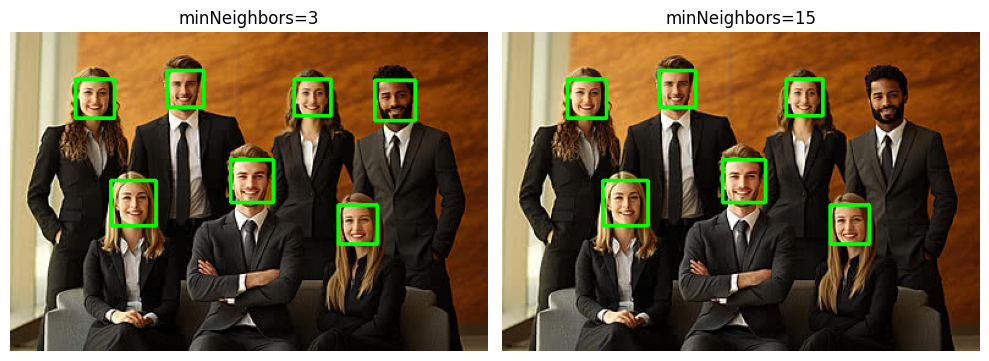

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with custom size (10 inch wide, 5 inch tall)
plt.figure(figsize=(10 ,5))

# Create first subplot (1 row, 2 columns, position 1)
plt.subplot(121); plt.imshow(img[..., ::-1]); plt.title("minNeighbors=3"); plt.axis("off")

# Create second subplot (1 row, 2 columns, postion 2)
plt.subplot(122); plt.imshow(copied_img[..., ::-1]); plt.title("minNeighbors=15"); plt.axis("off")

# Adjust spacing between subplots to prevent overlap
plt.tight_layout()
plt.show()
